In [1]:
# features
# - TEMA
# - EMA4, 9, 18 crossover
# - False Breakout Finder (*new intraday high, close lower than previous high, new intraday low, close higher than previous low
# - ATR
# - Relative Strength Analysis
# - market breadth (indicator of overall market performance)
# - skdj

import investpy
import pandas as pd
import numpy as np
import yfinance as yf
from itertools import combinations
import ta

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

In [2]:
# def download_data(ticker: str):
#     df = yf.download(ticker, period="10y", interval="1d", multi_level_index=False)
#     df.dropna(inplace=True)
#     return df

def calculate_indicators(df, close, high, low, vol):
    df['RSI'] = ta.momentum.RSIIndicator(df[close]).rsi()

    macd = ta.trend.MACD(df[close])
    df['MACD'] = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()
    df['MACD_Hist'] = macd.macd_diff()

    df['ATR'] = ta.volatility.AverageTrueRange(df[high], df[low], df[close]).average_true_range()

    df['TEMA'] = ta.trend.EMAIndicator(df[close], window=30).ema_indicator()
    df['EMA4'] = ta.trend.EMAIndicator(df[close], window=4).ema_indicator()
    df['EMA9'] = ta.trend.EMAIndicator(df[close], window=9).ema_indicator()
    df['EMA18'] = ta.trend.EMAIndicator(df[close], window=18).ema_indicator()

    df['OBV'] = ta.volume.OnBalanceVolumeIndicator(df[close], df[vol], fillna=True).on_balance_volume()
    df['VWAP'] = ta.volume.VolumeWeightedAveragePrice(df[high], df[low], df[close], df[vol], fillna=True).volume_weighted_average_price()
    # df['EMA4_Crossover_up'] = (df['EMA4'] > df['EMA9']) & (df['EMA9'] > df['EMA18'])
    # df['EMA4_Crossover_down'] = (df['EMA4'] < df['EMA9']) & (df['EMA9'] < df['EMA18'])

    stoch = ta.momentum.StochasticOscillator(df[high], df[low], df[close])
    df['SKDJ_K'] = stoch.stoch()
    df['SKDJ_D'] = stoch.stoch_signal()

    return df

def calculate_flags(df, high, low, close):
    df['Max_High'] = df[high].rolling(window=12).max().shift(-12)
    df['Min_Low'] = df[low].rolling(window=12).min().shift(-12)
    df['Flag'] = df.apply(lambda row:  2 if (row['Max_High'] > 1.005*row[close] and row['Min_Low'] < 0.995*row[close])
                                        else ((1 if row['Max_High'] > 1.005*row[close]
                                        else (-1 if row['Min_Low'] < 0.995*row[close]
                                        else 0))), axis=1)
    return df

def get_all_ratios(df, exclusion_list):
    feature_list = [col for col in df.columns.tolist() if col not in exclusion_list]
    new_columns = []
    for feat1, feat2 in combinations(feature_list, 2):
        column_name = f"{feat1}/{feat2}"
        new_columns.append((column_name, df[feat1] / df[feat2]))

    new_columns_df = pd.DataFrame(dict(new_columns))
    df = pd.concat([df, new_columns_df], axis=1)
    return df

def get_past_daily_ret(df, close):
    past_prices = []
    for i in range(0,30):
        column_name = f"Return_{i}"
        past_prices.append((column_name, df[close].shift(i)/df[close].shift(i+1)-1))
    past_prices_df = pd.DataFrame(dict(past_prices))
    df = pd.concat([df, past_prices_df], axis=1)
    return df


# def calculate_relative_strength(df, market):
#     df_market = yf.download(market, period="10y", interval="1d", multi_level_index=False)['Close'].rename(market)
#     df['market_close'] = df.merge(df_market, how='left', left_index=True, right_index=True)[market]
#     df['relative_strength'] = df['Close']/df['market_close']
#     df['relative_strength_EMA_4'] = ta.trend.EMAIndicator(df['relative_strength'], window=4).ema_indicator()
#     df['relative_strength_EMA_9'] = ta.trend.EMAIndicator(df['relative_strength'], window=9).ema_indicator()
#     return df

# def data_prep(ticker, market):
#     df = download_data(ticker)
#     df = calculate_indicators(df)
#     df = calculate_flags(df)
#     df = calculate_relative_strength(df, market)
#     df.drop(columns=['Max_High_2w', 'Min_Low_2w'], inplace=True)  # Clean up unnecessary columns
#     df.dropna(inplace=True)

    # return df
    # df.to_csv(f'{ticker}_processed.csv')
    # print(f'Data saved to {ticker}_processed.csv')

In [3]:
df =  pd.read_csv('Data/AUDNZD/AUDNZD_H1_201401012300_202504010800.csv', delimiter='\t',engine='python')
# df_iron = pd.read_csv('Data/AUDNZD/PIORECRUSDM.csv')
df['Date'] = pd.to_datetime(df['<DATE>'], format='%Y.%m.%d')
df['datetime'] = pd.to_datetime(df['<DATE>'] + ' ' + df['<TIME>'], format='%Y.%m.%d %H:%M:%S')
df['time'] = pd.to_datetime(df['<TIME>'], format='%H:%M:%S').dt.hour
df = calculate_indicators(df, '<CLOSE>', '<HIGH>', '<LOW>', '<TICKVOL>')
df = get_all_ratios(df, ['<DATE>','time','<TIME>','datetime','Date','<VOL>'])
df = get_past_daily_ret(df, '<CLOSE>')
df = calculate_flags(df,'<HIGH>','<LOW>','<CLOSE>')

In [4]:
df.set_index('datetime', inplace=True)

In [5]:
df['Flag'].value_counts()

Flag
 0    60044
-1     5120
 1     4666
 2      121
Name: count, dtype: int64

In [6]:
df

,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<TICKVOL>,<VOL>,<SPREAD>,Date,...,Return_23,Return_24,Return_25,Return_26,Return_27,Return_28,Return_29,Max_High,Min_Low,Flag
datetime,,,,,,,,,,,,,,,,,,,,,
2014-01-01 23:00:00,2014.01.01,23:00:00,1.08372,1.08465,1.08228,1.08307,1245,0,26,2014-01-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.08673,1.08151,0
2014-01-02 00:00:00,2014.01.02,00:00:00,1.08302,1.08474,1.08151,1.08335,1386,0,20,2014-01-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.08673,1.08269,0
2014-01-02 01:00:00,2014.01.02,01:00:00,1.08333,1.08475,1.08269,1.08362,2131,0,20,2014-01-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.08673,1.08290,0
2014-01-02 02:00:00,2014.01.02,02:00:00,1.08368,1.08465,1.08293,1.08317,3359,0,20,2014-01-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.08673,1.08290,0
2014-01-02 03:00:00,2014.01.02,03:00:00,1.08319,1.08484,1.08290,1.08445,2844,0,20,2014-01-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.08774,1.08337,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-31 20:00:00,2025.03.31,20:00:00,1.10068,1.10090,1.10055,1.10075,2568,0,11,2025-03-31,...,0.000427,0.000264,-0.000064,-0.000091,-0.000636,-0.000445,-0.000145,NaN,NaN,0
2025-03-31 21:00:00,2025.03.31,21:00:00,1.10073,1.10126,1.10072,1.10088,2785,0,11,2025-03-31,...,0.000091,0.000427,0.000264,-0.000064,-0.000091,-0.000636,-0.000445,NaN,NaN,0
2025-03-31 22:00:00,2025.03.31,22:00:00,1.10088,1.10115,1.10059,1.10066,1994,0,11,2025-03-31,...,-0.001063,0.000091,0.000427,0.000264,-0.000064,-0.000091,-0.000636,NaN,NaN,0


### Decision Tree Model

In [9]:
# Sort data by Date
df = df.sort_index()

# Split the data into train and test (20% test data)
# Define train-test split with a gap of 20 data points
train_size = int(0.8 * len(df))
train_data = df.iloc[:train_size].replace([np.inf, -np.inf], np.nan).dropna()
test_data = df.iloc[train_size + 100:].replace([np.inf, -np.inf], np.nan).dropna()  # Skipping 20 rows

# Features (excluding 'Date' and 'Flag' columns)
exclusion_list = ['datetime','<TIME>','Date','<DATE>','<VOL>','Flag','Max_High','Min_Low']
features = [col for col in df.columns.tolist() if col not in exclusion_list]

X_train = train_data[features]
y_train = train_data['Flag']==-1

X_test = test_data[features]
y_test = test_data['Flag']==-1

# 2) Logistic Regression with SequentialFeatureSelector and Cross-validation

# Initialize logistic regression model
# logreg = LogisticRegression(max_iter=10000)
# Initialize RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Initialize SequentialFeatureSelector for backward selection
# selector = SequentialFeatureSelector(rf, n_features_to_select='auto', direction='forward', scoring='roc_auc', cv=3, n_jobs=-1)

# Fit the feature selector on the training data
# selector = selector.fit(X_train, y_train)

# Get the selected features
# selected_features = selector.get_feature_names_out()
selected_features = features

# 3) Build Logistic Regression using selected features and evaluate AUROC with cross-validation
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Initialize the Logistic Regression model
rf.fit(X_train_selected, y_train)

# Perform cross-validation with AUROC as scoring metric
cv_scores = cross_val_score(rf, X_train_selected, y_train, cv=StratifiedKFold(3), scoring='roc_auc')

# Print the cross-validation AUROC scores
print(f"Cross-validation AUROC scores: {cv_scores}")
print(f"Mean AUROC: {cv_scores.mean()}")

# Evaluate AUROC on test data
y_pred_proba = rf.predict_proba(X_test_selected)[:, 1]
test_auroc = roc_auc_score(y_test, y_pred_proba)

print(f"AUROC on test data: {test_auroc}")

Cross-validation AUROC scores: [0.41495807 0.1139004  0.39751441]
Mean AUROC: 0.3087909590063022
AUROC on test data: 0.5040189247016555


# Catboost

In [7]:
# Sort data by Date
df = df.sort_index()

# Split the data into train and test (20% test data)
# Define train-test split with a gap of 20 data points
train_size = int(0.8 * len(df))
train_data = df.iloc[:train_size].replace([np.inf, -np.inf], np.nan).dropna()
test_data = df.iloc[train_size + 100:].replace([np.inf, -np.inf], np.nan).dropna()  # Skipping 20 rows

# Features (excluding 'Date' and 'Flag' columns)
exclusion_list = ['datetime','<TIME>','Date','<DATE>','<VOL>','Flag','Max_High','Min_Low']
features = [col for col in df.columns.tolist() if col not in exclusion_list]

X_train = train_data[features]
y_train = train_data['Flag']==-1

X_test = test_data[features]
y_test = test_data['Flag']==-1

# Initialize CatBoost model (silent mode)
cb = CatBoostClassifier(verbose=False, random_state=42)

# Hyperparameter space
param_dist = {'depth'         : [6,8,10],
              'learning_rate' : [0.01, 0.05, 0.1],
              'iterations'    : [30, 50, 100]
              }

# Randomized search with 3-fold CV
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_dist,
    scoring='roc_auc',
    cv=cv,
    n_iter=20,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the model
search.fit(X_train, y_train)

# Best model and parameters
best_cb = search.best_estimator_
print(f"Best Parameters: {search.best_params_}")

# Cross-validation AUROC score on training data
cv_scores = cross_val_score(best_cb, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"Cross-validation AUROC scores: {cv_scores}")
print(f"Mean AUROC: {cv_scores.mean()}")

# Evaluate on test data
y_pred_proba = best_cb.predict_proba(X_test)[:, 1]
test_auroc = roc_auc_score(y_test, y_pred_proba)
print(f"AUROC on test data: {test_auroc}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 500, 'depth': 8, 'border_count': 64}
Cross-validation AUROC scores: [0.82838676 0.81748597 0.82863085]
Mean AUROC: 0.8248345274552283
AUROC on test data: 0.6212544384565803


In [10]:
print(selected_features)


['<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<TICKVOL>', '<SPREAD>', 'time', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'ATR', 'TEMA', 'EMA4', 'EMA9', 'EMA18', 'OBV', 'VWAP', 'SKDJ_K', 'SKDJ_D', '<OPEN>/<HIGH>', '<OPEN>/<LOW>', '<OPEN>/<CLOSE>', '<OPEN>/<TICKVOL>', '<OPEN>/<SPREAD>', '<OPEN>/RSI', '<OPEN>/MACD', '<OPEN>/MACD_Signal', '<OPEN>/MACD_Hist', '<OPEN>/ATR', '<OPEN>/TEMA', '<OPEN>/EMA4', '<OPEN>/EMA9', '<OPEN>/EMA18', '<OPEN>/OBV', '<OPEN>/VWAP', '<OPEN>/SKDJ_K', '<OPEN>/SKDJ_D', '<HIGH>/<LOW>', '<HIGH>/<CLOSE>', '<HIGH>/<TICKVOL>', '<HIGH>/<SPREAD>', '<HIGH>/RSI', '<HIGH>/MACD', '<HIGH>/MACD_Signal', '<HIGH>/MACD_Hist', '<HIGH>/ATR', '<HIGH>/TEMA', '<HIGH>/EMA4', '<HIGH>/EMA9', '<HIGH>/EMA18', '<HIGH>/OBV', '<HIGH>/VWAP', '<HIGH>/SKDJ_K', '<HIGH>/SKDJ_D', '<LOW>/<CLOSE>', '<LOW>/<TICKVOL>', '<LOW>/<SPREAD>', '<LOW>/RSI', '<LOW>/MACD', '<LOW>/MACD_Signal', '<LOW>/MACD_Hist', '<LOW>/ATR', '<LOW>/TEMA', '<LOW>/EMA4', '<LOW>/EMA9', '<LOW>/EMA18', '<LOW>/OBV', '<LOW>/VWAP', '<LOW>/SK

In [78]:
X_test_results = X_test.copy()
X_test_results['predicted'] = y_pred_proba
X_test_results['actual'] = y_test

In [79]:
X_test_results.to_csv('Data/forex_model_prelim_results.csv')

In [80]:
# Import Joblib
import joblib
# Save the model to a file
joblib.dump(rf, 'model.joblib')

['model.joblib']

## Analysis of model results

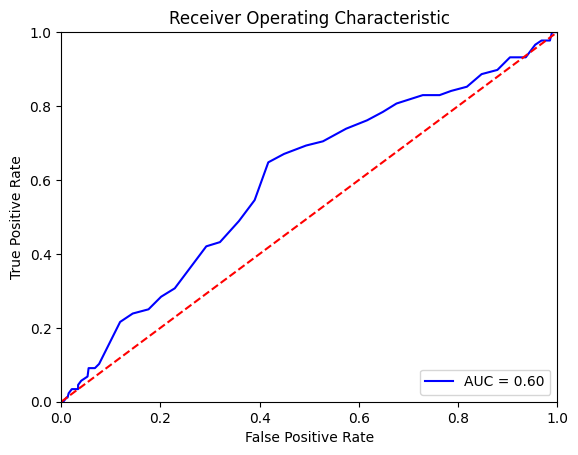

In [81]:
import sklearn.metrics as metrics
# calculate the fpr and tpr for all thresholds of the classification
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_proba)
roc_auc = metrics.auc(fpr, tpr)

# method I: plt
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [84]:
X_test_results

,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<TICKVOL>,<SPREAD>,RSI,MACD,MACD_Signal,MACD_Hist,...,Return_22,Return_23,Return_24,Return_25,Return_26,Return_27,Return_28,Return_29,predicted,actual
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-26,1.09624,1.09845,1.09521,1.09627,116532,21,64.587968,0.004345,0.003387,0.000958,...,0.003595,0.000703,0.000234,0.002207,0.012850,-0.000333,0.004450,-0.008832,0.17,True
2023-01-27,1.09618,1.09684,1.09406,1.09433,117528,21,62.250949,0.004712,0.003652,0.001060,...,-0.004263,0.003595,0.000703,0.000234,0.002207,0.012850,-0.000333,0.004450,0.17,False
2023-01-30,1.09339,1.09556,1.08962,1.09111,122149,21,58.469333,0.004689,0.003859,0.000829,...,-0.000112,-0.004263,0.003595,0.000703,0.000234,0.002207,0.012850,-0.000333,0.20,False
2023-01-31,1.09111,1.09610,1.08800,1.09494,124227,21,61.467695,0.004922,0.004072,0.000851,...,0.005078,-0.000112,-0.004263,0.003595,0.000703,0.000234,0.002207,0.012850,0.27,False
2023-02-01,1.09489,1.09927,1.09418,1.09643,143729,21,62.598977,0.005168,0.004291,0.000877,...,0.000550,0.005078,-0.000112,-0.004263,0.003595,0.000703,0.000234,0.002207,0.09,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-19,1.09231,1.09482,1.09091,1.09303,68624,11,25.383181,-0.003154,-0.001762,-0.001392,...,-0.000171,-0.004134,-0.000045,-0.000225,0.000386,0.004777,0.000416,0.001747,0.14,False
2025-03-20,1.09293,1.09617,1.09095,1.09449,75700,11,30.346634,-0.003348,-0.002079,-0.001269,...,0.005027,-0.000171,-0.004134,-0.000045,-0.000225,0.000386,0.004777,0.000416,0.09,False
2025-03-21,1.09365,1.09496,1.09126,1.09345,62994,11,28.873276,-0.003544,-0.002372,-0.001172,...,-0.001581,0.005027,-0.000171,-0.004134,-0.000045,-0.000225,0.000386,0.004777,0.19,False


In [85]:
for cutoff in range(0, 100):
    df = X_test_results[X_test_results['predicted']>cutoff/100.0]['actual'].value_counts(normalize=True)
    print(cutoff/100.0, " ", df[df.index == True].values)

0.0   [0.15714286]
0.01   [0.15714286]
0.02   [0.15714286]
0.03   [0.15742397]
0.04   [0.15770609]
0.05   [0.15855856]
0.06   [0.15607985]
0.07   [0.15837937]
0.08   [0.15858209]
0.09   [0.15648855]
0.1   [0.1611002]
0.11   [0.15991903]
0.12   [0.16317992]
0.13   [0.1626898]
0.14   [0.16629213]
0.15   [0.16859122]
0.16   [0.17505995]
0.17   [0.18205128]
0.18   [0.184]
0.19   [0.18715084]
0.2   [0.19345238]
0.21   [0.19935691]
0.22   [0.20748299]
0.23   [0.21771218]
0.24   [0.22440945]
0.25   [0.20689655]
0.26   [0.20283019]
0.27   [0.2010582]
0.28   [0.21142857]
0.29   [0.20645161]
0.3   [0.2]
0.31   [0.20833333]
0.32   [0.20952381]
0.33   [0.23595506]
0.34   [0.25333333]
0.35   [0.23333333]
0.36   [0.22222222]
0.37   [0.2]
0.38   [0.2]
0.39   [0.23529412]
0.4   [0.19354839]
0.41   [0.20833333]
0.42   [0.2]
0.43   [0.15789474]
0.44   [0.1875]
0.45   [0.23076923]
0.46   [0.22222222]
0.47   [0.14285714]
0.48   [0.16666667]
0.49   [0.16666667]
0.5   []
0.51   []
0.52   []
0.53   []
0.54  

In [88]:
X_test_results[X_test_results['predicted']>0.5]

,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<TICKVOL>,<SPREAD>,RSI,MACD,MACD_Signal,MACD_Hist,...,Return_22,Return_23,Return_24,Return_25,Return_26,Return_27,Return_28,Return_29,predicted,actual
Date,,,,,,,,,,,,,,,,,,,,,
2023-03-28,1.07279,1.07448,1.07077,1.07276,74128,21,42.942061,-0.004352,-0.004575,0.000223,...,-0.002342,-0.000805,-0.007946,-0.001937,0.003151,0.001911,0.000064,-0.002641,0.56,False
2023-06-07,1.09748,1.10311,1.09647,1.10179,88102,21,74.015750,0.006069,0.002408,0.003660,...,-0.003694,0.006279,-0.004857,-0.002320,-0.001805,0.005462,-0.008430,-0.000621,0.51,False
